# $\Psi_n$ diagnostic for Zhong & Wang (2024) Theorem 3.3

Target claim (proof step):
$$
\Psi_n(\hat\zeta,\hat h)=o_p(n^{-1/2})
\quad\Leftrightarrow\quad
S_n=\sqrt{n}\,\widehat\Psi \to_p 0.
$$

After joint DPLQR-style fitting of $(\hat\theta,\hat m)$, form residuals
$\hat r_i=Y_i-X_i\hat\theta-\hat m(Z_i)$ and the **oracle** residualized regressor
$\tilde X_i=X_i-\varphi^*(Z_i)$. Then
$$
\widehat\Psi
=
-\frac1n\sum_i\bigl[\tau-\mathbf{1}\{\hat r_i<0\}\bigr]\tilde X_i.
$$

Also record the ordinary $\theta$ score $G_\theta$ (same formula with $X_i$) and the
**frozen nuisance** $h$ one-dimensional convex adjustment
$$
\hat a=\arg\min_a\frac1n\sum_i\rho_\tau(\hat r_i-a\,\tilde X_i).
$$
The primary target is $S_n\to_p0$. Record both $|\hat a|$ and $\sqrt n\,|\hat a|$: unscaled shrinkage alone does not check the required rate. The adjustment is a supporting diagnostic; its relation to the score needs local curvature and regularity.

Homoskedastic PLQR toy DGP; joint Adam; fixed epochs; exact `phi_star`.

**Do not run the Monte Carlo until you intend to.** Outputs go under `./run/`.


## Configuration and imports


In [1]:
from __future__ import annotations

import json
import math
from pathlib import Path

import matplotlib

matplotlib.use("Agg")
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from scipy.optimize import linprog
from scipy import sparse

np.set_printoptions(precision=6, suppress=True)
torch.set_default_dtype(torch.float64)

# ---------------------------------------------------------------------------
# Config
# ---------------------------------------------------------------------------
N_VALUES = [500, 1000, 2000]
Q = 30
EPOCHS = 500
LEARNING_RATE = 1e-3
BATCH_SIZE = 128
HIDDEN = [16, 16]
BASE_SEED = 20260923
TAU = 0.5
if TAU != 0.5:
    raise ValueError("This DGP and training loss are configured for median regression (TAU = 0.5).")
THETA0 = 1.0
Z_DIM = 2

ROOT = Path(".").resolve()
RUN_DIR = ROOT / "run"
FIG_DIR = RUN_DIR / "figures"
RESULTS_CSV = RUN_DIR / "replication_results.csv"
SUMMARY_CSV = RUN_DIR / "summary.csv"
CONFIG_JSON = RUN_DIR / "config.json"

DEVICE = torch.device("cpu")


def replication_seed(n: int, rep: int) -> int:
    return int(BASE_SEED + 1_000_003 * n + 1_009 * rep)


print("ROOT =", ROOT)
print("N_VALUES =", N_VALUES, "Q =", Q, "EPOCHS =", EPOCHS, "HIDDEN =", HIDDEN)


ROOT = C:\Users\Tiansui Tu\Documents\GitHub\dplqr\results\2026-09-23_psi_n_thm33
N_VALUES = [500, 1000, 2000] Q = 30 EPOCHS = 500 HIDDEN = [16, 16]


## DGP helpers


In [2]:
def phi_star(Z: np.ndarray) -> np.ndarray:
    # Exact E[X|Z] under the DGP.
    Z = np.asarray(Z, dtype=np.float64)
    z1, z2 = Z[:, 0], Z[:, 1]
    return 0.5 + 0.3 * np.sin(2.0 * np.pi * z1) + 0.3 * z1 * z2


def m0_fn(Z: np.ndarray) -> np.ndarray:
    Z = np.asarray(Z, dtype=np.float64)
    z1, z2 = Z[:, 0], Z[:, 1]
    return (
        0.5 * np.sin(2.0 * np.pi * z1)
        + 0.5 * (z2 - 0.5) ** 2
        + 0.3 * np.cos(2.0 * np.pi * z1 * z2)
    )


def generate_sample(n: int, rng: np.random.Generator) -> dict:
    Z = rng.uniform(0.0, 1.0, size=(n, 2))
    phi = phi_star(Z)
    V = rng.normal(0.0, 0.5, size=n)
    X = phi + V
    m0 = m0_fn(Z)
    eps = rng.normal(0.0, 1.0, size=n)
    Y = THETA0 * X + m0 + eps
    X_tilde = X - phi
    return {
        "Y": Y.astype(np.float64),
        "X": X.astype(np.float64),
        "Z": Z.astype(np.float64),
        "X_tilde": X_tilde.astype(np.float64),
        "phi": phi.astype(np.float64),
        "m0": m0.astype(np.float64),
    }


def check_loss(resid: np.ndarray, tau: float = TAU) -> float:
    resid = np.asarray(resid, dtype=np.float64).ravel()
    return float(np.mean(resid * (tau - (resid < 0.0).astype(np.float64))))


# Sanity: E[X|Z] = phi_star (Monte Carlo smoke, not the experiment)
_rng = np.random.default_rng(0)
_Z = _rng.uniform(0, 1, size=(200_000, 2))
_V = _rng.normal(0, 0.5, size=200_000)
_X = phi_star(_Z) + _V
print("MC check mean(X - phi_star) ≈", float(np.mean(_X - phi_star(_Z))))


MC check mean(X - phi_star) ≈ 0.0013168380593364946


## Joint Adam model (scalar $\theta$ + MLP $m$)

Exactly `EPOCHS` epochs. No early stopping. No validation split.


In [3]:
class MLP(nn.Module):
    def __init__(self, in_dim: int = Z_DIM, hidden: list[int] | None = None):
        super().__init__()
        if hidden is None:
            hidden = list(HIDDEN)
        layers: list[nn.Module] = []
        d = in_dim
        for h in hidden:
            layers.append(nn.Linear(d, h))
            layers.append(nn.ReLU())
            d = h
        layers.append(nn.Linear(d, 1))
        self.net = nn.Sequential(*layers)

    def forward(self, z: torch.Tensor) -> torch.Tensor:
        return self.net(z).squeeze(-1)


class JointModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.theta = nn.Parameter(torch.tensor(0.0, dtype=torch.float64))
        self.m_net = MLP()

    def forward(self, X: torch.Tensor, Z: torch.Tensor) -> torch.Tensor:
        return X * self.theta + self.m_net(Z)


def train_joint(Y: np.ndarray, X: np.ndarray, Z: np.ndarray, seed: int):
    # Joint Adam for exactly EPOCHS epochs. Returns (theta_hat, m_hat, final_loss).
    torch.manual_seed(int(seed))
    np_rng = np.random.default_rng(int(seed))

    model = JointModel().to(DEVICE)
    opt = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

    Y_t = torch.as_tensor(Y, dtype=torch.float64, device=DEVICE)
    X_t = torch.as_tensor(X, dtype=torch.float64, device=DEVICE)
    Z_t = torch.as_tensor(Z, dtype=torch.float64, device=DEVICE)
    n = int(Y.shape[0])

    model.train()
    final_loss = float("nan")
    for _epoch in range(1, EPOCHS + 1):
        perm = np_rng.permutation(n)
        running = 0.0
        seen = 0
        for start in range(0, n, BATCH_SIZE):
            idx = perm[start : start + BATCH_SIZE]
            idx_t = torch.as_tensor(idx, dtype=torch.long, device=DEVICE)
            pred = model(X_t[idx_t], Z_t[idx_t])
            u = Y_t[idx_t] - pred
            loss = 0.5 * torch.mean(torch.abs(u))
            opt.zero_grad(set_to_none=True)
            loss.backward()
            opt.step()
            running += float(loss.detach().cpu()) * len(idx)
            seen += len(idx)
        final_loss = running / max(seen, 1)

    model.eval()
    with torch.no_grad():
        theta_hat = float(model.theta.detach().cpu())
        m_hat = model.m_net(Z_t).detach().cpu().numpy().astype(np.float64)
    return theta_hat, m_hat, float(final_loss)


print("train_joint defined")


train_joint defined


## Diagnostics: $\widehat\Psi$, $S_n$, $G_\theta$, $\hat a$

The LP uses $a\tilde X_i+u_i^+-u_i^-=\hat r_i$, so it minimizes the stated residual $\hat r_i-a\tilde X_i$. The previous minus sign on the first LP column returned $-\hat a$; its absolute value was unaffected. Sparse constraints avoid quadratic storage.


In [4]:
def a_hat_linprog(rhat: np.ndarray, X_tilde: np.ndarray, tau: float = TAU) -> float:
    # 1-D check-loss QR: min_a (1/n) sum rho_tau(rhat - a * X_tilde).
    r = np.asarray(rhat, dtype=np.float64).ravel()
    xt = np.asarray(X_tilde, dtype=np.float64).ravel()
    n = r.shape[0]
    # Variables: [a, u+, u-]; minimize tau*u+ + (1-tau)*u-
    # r - a*xt = u+ - u-
    c = np.concatenate([[0.0], tau * np.ones(n), (1.0 - tau) * np.ones(n)])
    # a*xt + u+ - u- = r, hence u+ - u- = r - a*xt.
    A_eq = sparse.hstack(
        [sparse.csr_matrix(xt.reshape(n, 1)), sparse.eye(n), -sparse.eye(n)],
        format="csr",
    )
    b_eq = r
    bounds = [(None, None)] + [(0.0, None)] * (2 * n)
    res = linprog(c, A_eq=A_eq, b_eq=b_eq, bounds=bounds, method="highs")
    if not res.success:
        raise RuntimeError(f"linprog failed: {res.message}")
    return float(res.x[0])


def replication_row(n: int, rep: int) -> dict:
    seed = replication_seed(n, rep)
    rng = np.random.default_rng(seed)
    data = generate_sample(n, rng)
    Y, X, Z, Xt = data["Y"], data["X"], data["Z"], data["X_tilde"]

    theta_hat, m_hat, final_loss = train_joint(Y, X, Z, seed)
    rhat = Y - X * theta_hat - m_hat
    ind = (rhat < 0.0).astype(np.float64)
    score = TAU - ind  # tau - 1{r<0}

    Psi_hat = -float(np.mean(score * Xt))
    G_theta = -float(np.mean(score * X))
    sqrt_n = math.sqrt(n)
    Sn = sqrt_n * Psi_hat
    sqrt_n_G = sqrt_n * G_theta
    a_hat = a_hat_linprog(rhat, Xt, TAU)

    return {
        "n": int(n),
        "rep": int(rep),
        "seed": int(seed),
        "theta_hat": float(theta_hat),
        "theta_error": float(theta_hat - THETA0),
        "Psi_hat": float(Psi_hat),
        "Sn": float(Sn),
        "abs_Sn": float(abs(Sn)),
        "G_theta": float(G_theta),
        "sqrt_n_G_theta": float(sqrt_n_G),
        "abs_sqrt_n_G_theta": float(abs(sqrt_n_G)),
        "a_hat": float(a_hat),
        "abs_a_hat": float(abs(a_hat)),
        "sqrt_n_a_hat": float(sqrt_n * a_hat),
        "abs_sqrt_n_a_hat": float(sqrt_n * abs(a_hat)),
        "final_training_loss": float(final_loss),
    }


print("diagnostics defined")


diagnostics defined


## Write config (does not run Monte Carlo)


In [5]:
RUN_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

config = {
    "purpose": "Psi_n = o_p(n^{-1/2}) diagnostic for ZW Theorem 3.3",
    "N_VALUES": N_VALUES,
    "Q": Q,
    "EPOCHS": EPOCHS,
    "LEARNING_RATE": LEARNING_RATE,
    "BATCH_SIZE": BATCH_SIZE,
    "HIDDEN": HIDDEN,
    "BASE_SEED": BASE_SEED,
    "TAU": TAU,
    "THETA0": THETA0,
    "DGP": {
        "Z": "Uniform(0,1)^2",
        "phi_star": "0.5 + 0.3*sin(2*pi*Z1) + 0.3*Z1*Z2",
        "X": "phi_star(Z) + N(0,0.5^2)",
        "m0": "0.5*sin(2*pi*Z1) + 0.5*(Z2-0.5)^2 + 0.3*cos(2*pi*Z1*Z2)",
        "epsilon": "N(0,1)",
        "Y": "theta0*X + m0(Z) + epsilon",
    },
    "fitting": "joint Adam (theta, m_NN); no early stopping",
    "seed_formula": "BASE_SEED + 1000003*n + 1009*rep",
}
CONFIG_JSON.write_text(json.dumps(config, indent=2), encoding="utf-8")
print("Wrote", CONFIG_JSON)


Wrote C:\Users\Tiansui Tu\Documents\GitHub\dplqr\results\2026-09-23_psi_n_thm33\run\config.json


## Monte Carlo loop (restartable)

Skips completed `(n, rep)` pairs already in `run/replication_results.csv`.

Use a fresh output directory whenever changing the DGP, optimizer, network, or diagnostic definitions. The restart key checks only `(n, rep)`, not the configuration.


In [6]:
def load_completed() -> set[tuple[int, int]]:
    if not RESULTS_CSV.exists():
        return set()
    df = pd.read_csv(RESULTS_CSV)
    return {(int(r.n), int(r.rep)) for r in df.itertuples(index=False)}


def append_row(row: dict) -> None:
    df = pd.DataFrame([row])
    header = not RESULTS_CSV.exists()
    df.to_csv(RESULTS_CSV, mode="a", header=header, index=False)


completed = load_completed()
print(f"Already completed: {len(completed)} rows")

for n in N_VALUES:
    for rep in range(1, Q + 1):
        key = (n, rep)
        if key in completed:
            continue
        row = replication_row(n, rep)
        append_row(row)
        completed.add(key)
        print(
            f"n={n} rep={rep}/{Q}  "
            f"theta={row['theta_hat']:.4f}  "
            f"|Sn|={row['abs_Sn']:.4f}  "
            f"|sqrt_n G|={row['abs_sqrt_n_G_theta']:.4f}  "
            f"|a|={row['abs_a_hat']:.4f}"
        )

print("Done. Wrote", RESULTS_CSV)


Already completed: 0 rows
n=500 rep=1/30  theta=0.9892  |Sn|=0.2926  |sqrt_n G|=0.3148  |a|=0.1600
n=500 rep=2/30  theta=0.9169  |Sn|=0.0818  |sqrt_n G|=0.0069  |a|=0.0243
n=500 rep=3/30  theta=0.9131  |Sn|=0.0858  |sqrt_n G|=0.0513  |a|=0.0046
n=500 rep=4/30  theta=0.8324  |Sn|=0.1154  |sqrt_n G|=0.1025  |a|=0.1352
n=500 rep=5/30  theta=1.0383  |Sn|=0.2872  |sqrt_n G|=0.3771  |a|=0.0809
n=500 rep=6/30  theta=1.0327  |Sn|=0.0301  |sqrt_n G|=0.0127  |a|=0.0114
n=500 rep=7/30  theta=0.9098  |Sn|=0.1053  |sqrt_n G|=0.1379  |a|=0.0440
n=500 rep=8/30  theta=0.9055  |Sn|=0.1314  |sqrt_n G|=0.2250  |a|=0.0824
n=500 rep=9/30  theta=0.9740  |Sn|=0.2633  |sqrt_n G|=0.3445  |a|=0.1464
n=500 rep=10/30  theta=1.0012  |Sn|=0.0516  |sqrt_n G|=0.1550  |a|=0.0090
n=500 rep=11/30  theta=1.0116  |Sn|=0.1176  |sqrt_n G|=0.1775  |a|=0.0516
n=500 rep=12/30  theta=0.9319  |Sn|=0.1346  |sqrt_n G|=0.1868  |a|=0.0553
n=500 rep=13/30  theta=0.9902  |Sn|=0.1738  |sqrt_n G|=0.2567  |a|=0.1781
n=500 rep=14/30  thet

## Summary table and four plots

Inspect the distribution of $|S_n|$, including upper quantiles and exceedance frequencies. Convergence in probability requires $P(|S_n|>\epsilon)\to0$ for every fixed $\epsilon>0$. The thresholds below are descriptive diagnostics, not hypothesis tests.


   n  Q  mean_theta_hat  bias_theta  mean_abs_Sn  sd_abs_Sn  mc_se_mean_abs_Sn  median_abs_Sn  q90_abs_Sn  prob_abs_Sn_gt_0_1  prob_abs_Sn_gt_0_25  mean_abs_sqrt_n_G_theta  sd_abs_sqrt_n_G_theta  mean_abs_a_hat  sd_abs_a_hat  mean_abs_sqrt_n_a_hat  sd_abs_sqrt_n_a_hat   mean_Sn  mean_G_theta
 500 30        0.932926   -0.067074     0.117319   0.074145           0.013537       0.103519    0.264121            0.566667             0.133333                 0.154253               0.103368        0.050112      0.047526               1.120540             1.062719 -0.073048     -0.006634
1000 30        1.024426    0.024426     0.080656   0.057511           0.010500       0.072692    0.157349            0.233333             0.000000                 0.112526               0.079385        0.017392      0.016075               0.549971             0.508332  0.065485      0.000012
2000 30        1.015973    0.015973     0.069951   0.058476           0.010676       0.044180    0.160949            0.33

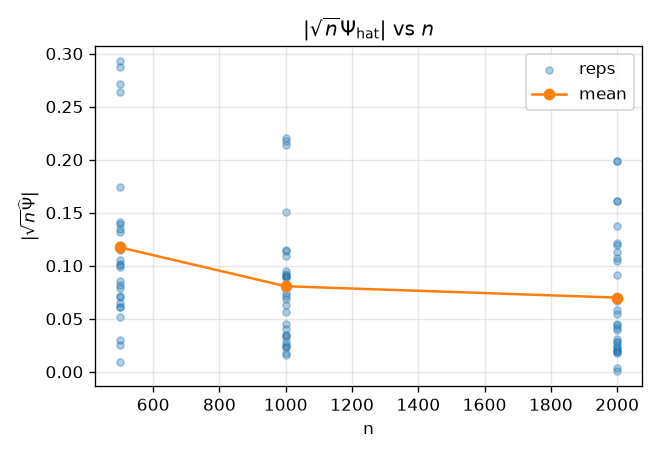

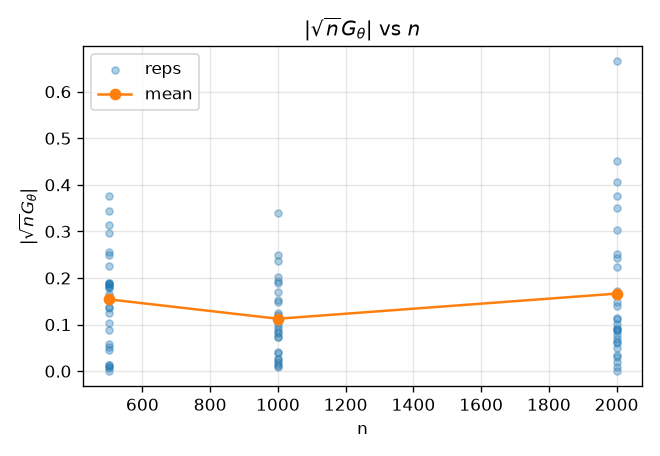

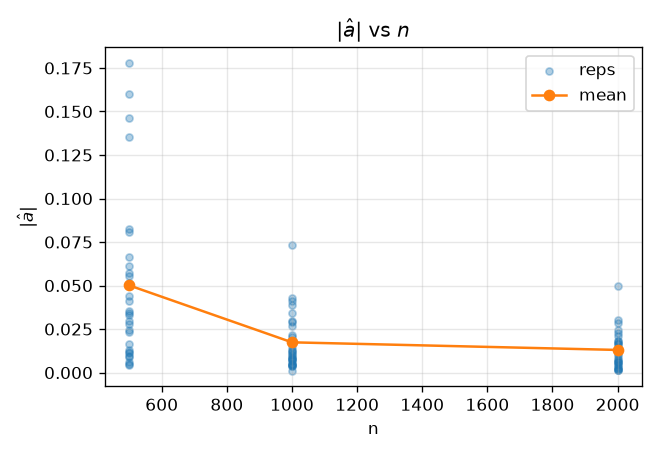

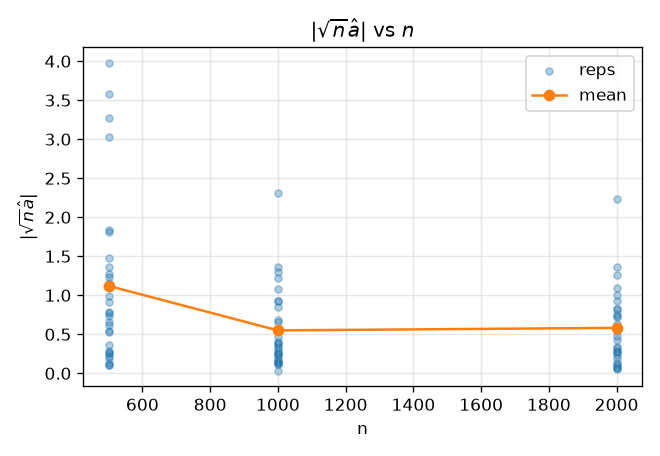

Wrote figures under C:\Users\Tiansui Tu\Documents\GitHub\dplqr\results\2026-09-23_psi_n_thm33\run\figures


In [7]:
if not RESULTS_CSV.exists():
    raise FileNotFoundError("Run the Monte Carlo cell first to create replication_results.csv")

df = pd.read_csv(RESULTS_CSV)
# This also permits summaries of older rows that stored only abs_a_hat.
df["abs_sqrt_n_a_hat"] = np.sqrt(df["n"]) * df["abs_a_hat"]

rows = []
for n, g in df.groupby("n"):
    rows.append(
        {
            "n": int(n),
            "Q": int(len(g)),
            "mean_theta_hat": float(g["theta_hat"].mean()),
            "bias_theta": float(g["theta_error"].mean()),
            "mean_abs_Sn": float(g["abs_Sn"].mean()),
            "sd_abs_Sn": float(g["abs_Sn"].std(ddof=1)),
            "mc_se_mean_abs_Sn": float(g["abs_Sn"].std(ddof=1) / math.sqrt(len(g))),
            "median_abs_Sn": float(g["abs_Sn"].median()),
            "q90_abs_Sn": float(g["abs_Sn"].quantile(0.9)),
            "prob_abs_Sn_gt_0_1": float((g["abs_Sn"] > 0.1).mean()),
            "prob_abs_Sn_gt_0_25": float((g["abs_Sn"] > 0.25).mean()),
            "mean_abs_sqrt_n_G_theta": float(g["abs_sqrt_n_G_theta"].mean()),
            "sd_abs_sqrt_n_G_theta": float(g["abs_sqrt_n_G_theta"].std(ddof=1)),
            "mean_abs_a_hat": float(g["abs_a_hat"].mean()),
            "sd_abs_a_hat": float(g["abs_a_hat"].std(ddof=1)),
            "mean_abs_sqrt_n_a_hat": float(g["abs_sqrt_n_a_hat"].mean()),
            "sd_abs_sqrt_n_a_hat": float(g["abs_sqrt_n_a_hat"].std(ddof=1)),
            "mean_Sn": float(g["Sn"].mean()),
            "mean_G_theta": float(g["G_theta"].mean()),
        }
    )
summary = pd.DataFrame(rows).sort_values("n")
summary.to_csv(SUMMARY_CSV, index=False)
print(summary.to_string(index=False))
print("Wrote", SUMMARY_CSV)


def _scatter_mean(ax, n_col, y_col, ylabel, title, fname):
    ax.scatter(df[n_col], df[y_col], alpha=0.35, s=18, label="reps")
    means = df.groupby(n_col)[y_col].mean()
    ax.plot(means.index, means.values, "o-", color="C1", label="mean")
    ax.set_xlabel("n")
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.legend()
    ax.grid(True, alpha=0.3)
    fig = ax.figure
    fig.tight_layout()
    fig.savefig(FIG_DIR / fname, dpi=120)
    from IPython.display import Image, display
    display(Image(filename=str(FIG_DIR / fname)))
    plt.close(fig)


fig, ax = plt.subplots(figsize=(5.5, 3.8))
_scatter_mean(ax, "n", "abs_Sn", r"$|\sqrt{n}\widehat\Psi|$", r"$|\sqrt{n}\Psi_{\mathrm{hat}}|$ vs $n$", "abs_Sn_vs_n.png")

fig, ax = plt.subplots(figsize=(5.5, 3.8))
_scatter_mean(
    ax,
    "n",
    "abs_sqrt_n_G_theta",
    r"$|\sqrt{n} G_\theta|$",
    r"$|\sqrt{n} G_\theta|$ vs $n$",
    "abs_sqrt_n_Gtheta_vs_n.png",
)

fig, ax = plt.subplots(figsize=(5.5, 3.8))
_scatter_mean(ax, "n", "abs_a_hat", r"$|\hat a|$", r"$|\hat a|$ vs $n$", "abs_ahat_vs_n.png")

fig, ax = plt.subplots(figsize=(5.5, 3.8))
_scatter_mean(
    ax, "n", "abs_sqrt_n_a_hat", r"$|\sqrt{n}\hat a|$",
    r"$|\sqrt{n}\hat a|$ vs $n$", "abs_sqrt_n_ahat_vs_n.png",
)

print("Wrote figures under", FIG_DIR)


## Descriptive summary (does not establish an asymptotic limit)


In [8]:
s = summary.sort_values("n")
print("=== Finite-sample diagnostics for the fitted Adam estimator ===")
for label, column in [
    ("mean |sqrt(n) Psi_hat|", "mean_abs_Sn"),
    ("90th percentile of |sqrt(n) Psi_hat|", "q90_abs_Sn"),
    ("fraction |sqrt(n) Psi_hat| > 0.1", "prob_abs_Sn_gt_0_1"),
    ("fraction |sqrt(n) Psi_hat| > 0.25", "prob_abs_Sn_gt_0_25"),
    ("mean |sqrt(n) G_theta|", "mean_abs_sqrt_n_G_theta"),
    ("mean |a_hat|", "mean_abs_a_hat"),
    ("mean |sqrt(n) a_hat|", "mean_abs_sqrt_n_a_hat"),
]:
    print(label + ":", dict(zip(s["n"].astype(int), s[column].astype(float))))

if len(s) >= 2:
    first, last = s["mean_abs_Sn"].iloc[[0, -1]]
    if first > 0:
        print(f"Largest/smallest-n ratio of mean |Sn|: {last / first:.3f}")
print("A decrease is descriptive evidence over this n grid; it is not proof of convergence to zero.")
print("Check Monte Carlo uncertainty, tails, larger n, and sensitivity to optimization and network size.")
print("Small ordinary theta scores or unscaled a_hat alone do not establish the projected-score rate.")
print("This notebook does not separately evaluate the empirical-process or population Taylor remainder.")


=== Finite-sample diagnostics for the fitted Adam estimator ===
mean |sqrt(n) Psi_hat|: {500: 0.11731852266507445, 1000: 0.08065603956079442, 2000: 0.06995123683238225}
90th percentile of |sqrt(n) Psi_hat|: {500: 0.2641207954146369, 1000: 0.1573488381357425, 2000: 0.160949060648122}
fraction |sqrt(n) Psi_hat| > 0.1: {500: 0.5666666666666667, 1000: 0.23333333333333334, 2000: 0.3333333333333333}
fraction |sqrt(n) Psi_hat| > 0.25: {500: 0.13333333333333333, 1000: 0.0, 2000: 0.0}
mean |sqrt(n) G_theta|: {500: 0.15425343740859815, 1000: 0.11252569335002355, 2000: 0.16649827038370385}
mean |a_hat|: {500: 0.05011209392750431, 1000: 0.017391621898652437, 2000: 0.013016015156935564}
mean |sqrt(n) a_hat|: {500: 1.1205404851675405, 1000: 0.5499713740420377, 2000: 0.5820938937415102}
Largest/smallest-n ratio of mean |Sn|: 0.596
A decrease is descriptive evidence over this n grid; it is not proof of convergence to zero.
Check Monte Carlo uncertainty, tails, larger n, and sensitivity to optimization

## What this notebook can and cannot check

**Yes: it directly probes the fitted projected-score step**
$\Psi_n(\hat\zeta,\hat h)=o_p(n^{-1/2})$ for this numerical estimator.
**It does not establish the full asymptotic expansion or prove Theorem 3.3.**
At review time the notebook was unexecuted and its folder contained no Monte Carlo results.

### Why the implemented score is the right one

The supplement, pp. 4–5, defines

$$
\hat\zeta=\hat\theta-\theta_0,\qquad
\hat h(z)=\hat m(z)-m_0(z)+\hat\zeta\,\varphi^*(z).
$$

Consequently,

$$
\epsilon_i-\hat\zeta\tilde X_i-\hat h(Z_i)
=Y_i-X_i\hat\theta-\hat m(Z_i)=\hat r_i.
$$

So `Psi_hat` evaluates the stated $\Psi_n(\hat\zeta,\hat h)$ without explicitly constructing
$\hat h$. For the independent normal errors used here, $f(0\mid X,Z)$ is constant,
and the oracle $\varphi^*(Z)=E[X\mid Z]$ is the correct weighted projection.
The same formula generally needs a density-weighted projection under heteroskedasticity.
Use the **training sample** for this score: it is the empirical loss score at its fitted estimator.

### The optimization step needs checking

The ordinary parameter score and the projected score satisfy

$$
\widehat\Psi
=G_\theta+\frac1n\sum_{i=1}^n
\bigl[\tau-\mathbf1\{\hat r_i<0\}\bigr]\varphi^*(Z_i).
$$

Thus a small $G_\theta$ alone is insufficient. The frozen-$h$ move is

$$
\theta(a)=\hat\theta+a,\qquad
m_a(z)=\hat m(z)-a\varphi^*(z),\qquad
r_i(a)=\hat r_i-a\tilde X_i.
$$

The supplement's proof uses minimization along this direction. A fixed neural-network class
need not contain $m_a$, and finite-epoch Adam need not reach even the original joint minimum.
The auxiliary LP is useful for measuring the missing directional adjustment; it does not
make the original estimator a minimizer. Keep its result diagnostic rather than replacing
$\hat\theta$ with the adjusted estimate when assessing the original algorithm.

Raw $|\hat a|\to0$ is too weak for the desired score rate. Under suitable local curvature
and stochastic regularity, the expected relation is
$\hat a\approx-\widehat\Psi/J$, where

$$
J=E[f(0\mid X,Z)\tilde X^2]
=\frac{0.25}{\sqrt{2\pi}}>0
$$

for this DGP. Hence also inspect $\sqrt n\,|\hat a|$.
At exact zero residuals, the strict-indicator score selects a subgradient endpoint;
an exact quantile-regression optimum need not make that selected score exactly zero.

### What is missing for a full expansion check

With $\Psi_0$ denoting the population score and $\Psi_0(0,0)=0$, define

$$
\begin{aligned}
E_n&=\sqrt n\left\{(\Psi_n-\Psi_0)(\hat\zeta,\hat h)
                         -(\Psi_n-\Psi_0)(0,0)\right\},\\
T_n&=\sqrt n\left\{\Psi_0(\hat\zeta,\hat h)-J\hat\zeta\right\}.
\end{aligned}
$$

The exact decomposition is

$$
J\sqrt n\,(\hat\theta-\theta_0)+\sqrt n\,\Psi_n(0,0)
=S_n-E_n-T_n.
$$

The notebook measures $S_n$, but does not separately measure $E_n$ or $T_n$.
All three being $o_p(1)$ would give the usual linear expansion, with sign and normalization
derived from the score defined above. Even at the truth, $\sqrt n\,\Psi_n(0,0)$ normally
has a nondegenerate limit; it is not the score that should vanish.
A fuller experiment should record the left-hand side and, using the known DGP and a sufficiently
accurate independent integration sample, estimate the two remainder terms.

### Limits of the current experiment

- The grid $n\in\{500,1000,2000\}$ and 30 replications gives a small finite-sample comparison.
  Inspect Monte Carlo uncertainty and tail frequencies; endpoint decreases cannot certify a limit.
- The network width is fixed at `[16, 16]`, while the theorem assumes a network class that grows
  with $n$ (Assumption 4). Fixed learning rate and 500 epochs also leave optimization error uncontrolled.
- Gaussian $X-\varphi^*(Z)$ makes $X$ unbounded, outside the theorem's compact-covariate
  Assumption 2. This is a diagnostic toy model, not an exact replication of all assumptions.
- `TAU = 0.5` is essential to this normal-error DGP and the absolute-loss training code;
  a guard now rejects other values.
- `final_training_loss` is the average batch loss during the last epoch, not a reevaluation
  at the returned parameters. The projected score itself is evaluated at the returned fit.
- Restarting checks only `(n, rep)`, and `ROOT` is the kernel working directory. Run from this
  notebook's folder and use a fresh output directory for each changed configuration.

Sources: [main paper](../../Zhong%20and%20Wang%202024%20JBES.pdf), Section 3 and Theorem 3.3;
[supplement](../../Zhong%20and%20Wang%202024%20JBES%20supplement.pdf), pp. 4–6.
